# Model Improvement and Threshold Tuning

In this notebook, we improve the baseline modeling workflow by creating a validation set, comparing candidate models, analyzing precision-recall behavior, tuning the classification threshold, and evaluating the final selected model on the untouched test set.

The main goal is not simply to maximize accuracy, but to improve failure detection in a realistic predictive maintenance setting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
    RocCurveDisplay
)

## Imports

The required libraries are imported for preprocessing, model training, evaluation, precision-recall analysis, and threshold tuning.

In [2]:
df = pd.read_csv('../data/raw/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


#### Feature Engineering

In [3]:
df['Temp_diff [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']

df['Power [W]'] = (
    df['Torque [Nm]'] *
    df['Rotational speed [rpm]'] *
    2 * np.pi / 60
)

df['Torque_Wear'] = df['Torque [Nm]'] * df['Tool wear [min]']

#### Defining Features and Target columns

In [4]:
target = 'Machine failure'
leakage_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
id_cols = ['UDI', 'Product ID']

X = df.drop(columns=[target] + leakage_cols + id_cols)
y = df[target]
y.value_counts(normalize = True) *100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [5]:
categorical_features = ['Type']
numerical_features = X.drop(columns=categorical_features).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_diff [K]', 'Power [W]', 'Torque_Wear']

Categorical features:
['Type']


#### Splitting training, cross validation and testing data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Testing distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


In [8]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

In [9]:
print("Training subset distribution:")
print(y_train_sub.value_counts(normalize=True) * 100)

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training subset distribution:
Machine failure
0    96.616667
1     3.383333
Name: proportion, dtype: float64

Validation distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64

Test distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


### Preprocessing

In [10]:
numeric_transformer = Pipeline(steps = [
    ('scaler',StandardScaler())
])

categorical_transformer = Pipeline(steps =[
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num',numeric_transformer,numerical_features),
    ('cat',categorical_transformer,categorical_features)
])

### Defining Candidate models
1. logistic regression
2. random forest
3. extra trees

In [11]:
models = {
    "Logistic Regression" : Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('classifier',LogisticRegression(
            max_iter=1000,
            class_weight= 'balanced',
            random_state= 42
        ))
    ]),
    "Random Forest" : Pipeline(steps=[
        ('preprocessor',preprocessor),
        ('classifier',RandomForestClassifier(
            n_estimators=300,
            class_weight= 'balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "Extra Trees": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', ExtraTreesClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])
}

Three models were compared:

- Logistic Regression: simple and interpretable baseline
- Random Forest: nonlinear ensemble model
- Extra Trees: highly randomized tree-based ensemble

All models use class balancing to reduce the effect of class imbalance.

Three models were compared:

- Logistic Regression: simple and interpretable baseline
- Random Forest: nonlinear ensemble model
- Extra Trees: highly randomized tree-based ensemble

All models use class balancing to reduce the effect of class imbalance.

### Creating a validation evaluation function

In [12]:
def evaluate_on_validation(model,X_val,y_val,model_name):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:,1]
    
    results = {
        "Model":model_name,
        "Precision":precision_score(y_val,y_pred,zero_division=0),
        "Recall":recall_score(y_val,y_pred,zero_division=0),
        "F1_score":f1_score(y_val,y_pred,zero_division=0),
        "ROC_AUC":roc_auc_score(y_val,y_proba),
        "PR_AUC":average_precision_score(y_val,y_proba)
    }
    
    print(f"===== {model_name} =====")
    print(classification_report(y_val,y_pred,zero_division=0))
    cm = confusion_matrix(y_val, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print()
    
    return results
    
    

In [13]:
validation_results = []

for model_name, model in models.items():
    model.fit(X_train_sub,y_train_sub)

    result = evaluate_on_validation(
        model,
        X_val,
        y_val,
        model_name
    )

    validation_results.append(result)
    
validation_results_df = pd.DataFrame(validation_results)
validation_results_df

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      1932
           1       0.15      0.82      0.26        68

    accuracy                           0.84      2000
   macro avg       0.57      0.83      0.58      2000
weighted avg       0.96      0.84      0.89      2000

Confusion Matrix:
[[1624  308]
 [  12   56]]

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       1.00      0.66      0.80        68

    accuracy                           0.99      2000
   macro avg       0.99      0.83      0.90      2000
weighted avg       0.99      0.99      0.99      2000

Confusion Matrix:
[[1932    0]
 [  23   45]]

===== Extra Trees =====
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       1.00      0.51      0.68        68

    accu

,Model,Precision,Recall,F1_score,ROC_AUC,PR_AUC
0,Logistic Regression,0.153846,0.823529,0.259259,0.920838,0.434578
1,Random Forest,1.000000,0.661765,0.796460,0.974390,0.854503
2,Extra Trees,1.000000,0.514706,0.679612,0.962931,0.794460


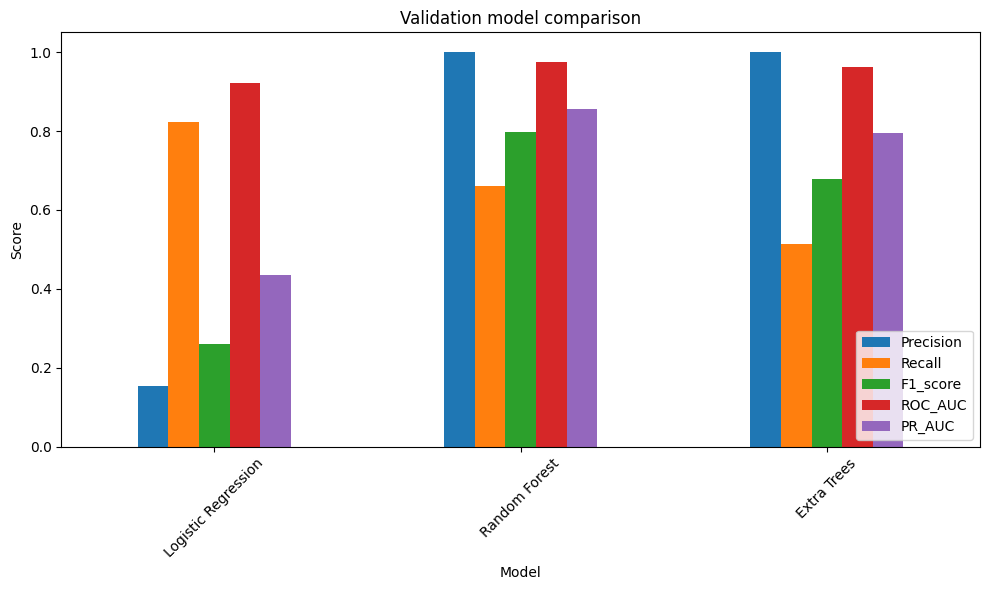

In [14]:
plot=validation_results_df.set_index('Model').plot(
    kind = 'bar',
    figsize=(10,6)
)
plt.title('Validation model comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/day4_validation_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


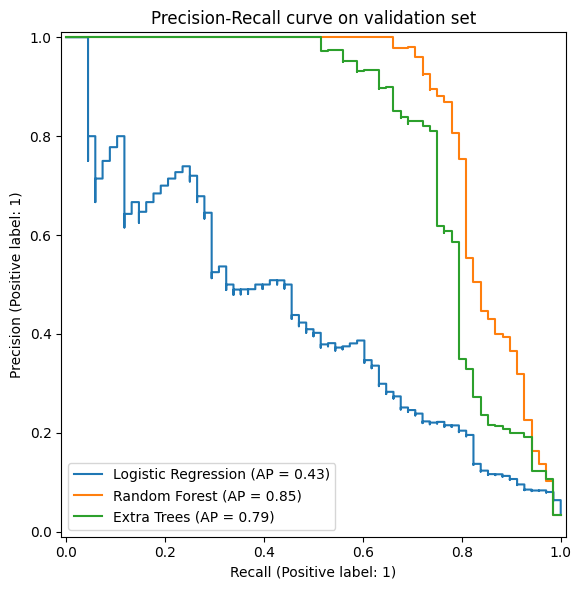

In [15]:
plt.figure(figsize=(8,6))

for model_name, model in models.items():
    y_val_proba = model.predict_proba(X_val)[:,1]
    
    PrecisionRecallDisplay.from_predictions(
        y_val,
        y_val_proba,
        name = model_name,
        ax=plt.gca()
    )

plt.title('Precision-Recall curve on validation set')
plt.tight_layout()

plt.savefig('../reports/figures/day4_precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

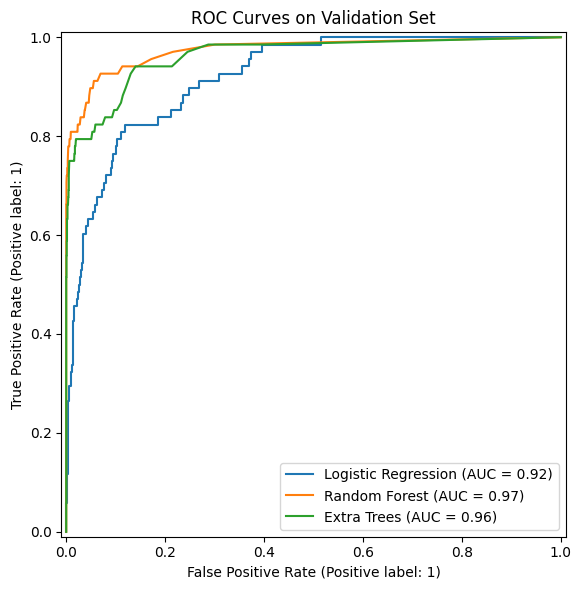

In [16]:
plt.figure(figsize=(8,6))

for model_name, model in models.items():
    y_val_proba = model.predict_proba(X_val)[:,1]
    
    RocCurveDisplay.from_predictions(
        y_val,
        y_val_proba,
        name = model_name,
        ax=plt.gca()
    )
plt.title('ROC Curves on Validation Set')
plt.tight_layout()

plt.savefig('../reports/figures/day4_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
best_model_name = validation_results_df.sort_values(
    by='PR_AUC',
    ascending=False
).iloc[0]['Model']
print(best_model_name)
# This returns the best model according to PR_AUC Score.
# We chose PR_AUC because it is a better metric for imbalanced data where the positive class(machine failure) is rare
best_model = models[best_model_name]

Random Forest


## Threshold Tuning

The classification threshold controls how sensitive the model is when predicting machine failure.

Lower thresholds usually increase recall but may create more false alarms. Higher thresholds usually increase precision but may miss more failures.

Specifically for this project, we care more about recall than precision because missing a real failure can be more expensive than an unnecessary inspection

In [18]:
y_val_proba = best_model.predict_proba(X_val)[:,1]
precision, recall, thresholds = precision_recall_curve(y_val,y_val_proba)

threshold_df = pd.DataFrame({
    'Threshold' : thresholds,
    'Precision' : precision[:-1],
    'Recall' : recall[:-1]
})
threshold_df['F1_score'] = (
    2 * threshold_df['Precision'] * threshold_df['Recall']
) / (
    threshold_df['Precision'] + threshold_df['Recall']
)
threshold_df.head()

,Threshold,Precision,Recall,F1_score
0,0.000000,0.034000,1.000000,0.065764
1,0.003333,0.103395,0.985294,0.187151
2,0.006667,0.136646,0.970588,0.239564
3,0.010000,0.163728,0.955882,0.279570
4,0.013333,0.186589,0.941176,0.311436


In [19]:
threshold_df.sort_values(by='F1_score', ascending=False).head(10)

,Threshold,Precision,Recall,F1_score
64,0.433333,0.960784,0.720588,0.823529
56,0.300000,0.868852,0.779412,0.821705
65,0.436667,0.979592,0.705882,0.820513
61,0.396667,0.925926,0.735294,0.819672
57,0.303333,0.881356,0.764706,0.818898
63,0.426667,0.942308,0.720588,0.816667
58,0.346667,0.894737,0.750000,0.816000
55,0.266667,0.854839,0.779412,0.815385
60,0.390000,0.909091,0.735294,0.813008
66,0.463333,0.979167,0.691176,0.810345


In [20]:
# Setting a minimum acceptable recall target
min_recall = 0.80

candidate_thresholds = threshold_df[threshold_df['Recall'] >= min_recall]

candidate_thresholds.sort_values(by='Precision', ascending=False).head(10)

,Threshold,Precision,Recall,F1_score
47,0.190000,0.753425,0.808824,0.780142
46,0.183333,0.743243,0.808824,0.774648
45,0.173333,0.733333,0.808824,0.769231
44,0.170000,0.723684,0.808824,0.763889
43,0.160000,0.714286,0.808824,0.758621
42,0.153333,0.687500,0.808824,0.743243
41,0.146667,0.679012,0.808824,0.738255
40,0.143333,0.654762,0.808824,0.723684
39,0.130000,0.639535,0.808824,0.714286
38,0.126667,0.617978,0.808824,0.700637


In [21]:
best_threshold = candidate_thresholds.sort_values(
    by='Precision',
    ascending= False
).iloc[0]['Threshold']
best_threshold

np.float64(0.19)

A minimum recall target of 80% was selected to prioritize detecting actual failures.

Among all thresholds that achieved at least 80% recall, the threshold with the highest precision was selected. This balances failure detection with controlling false alarms. Even with a slight trade-off in F1 score

## Model Threshold Evaluation

In [22]:
def evaluate_with_threshold(model, X, y, threshold, model_name):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred_threshold = (y_proba >= threshold).astype(int)

    print(f"===== {model_name} at Threshold {threshold:.3f} =====")
    print(classification_report(y, y_pred_threshold, zero_division=0))

    cm = confusion_matrix(y, y_pred_threshold)
    print("Confusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{model_name} - Threshold {threshold:.3f}')
    plt.tight_layout()
    plt.show()

    results = {
        "Model": model_name,
        "Threshold": threshold,
        "Precision": precision_score(y, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y, y_pred_threshold, zero_division=0),
        "F1 Score": f1_score(y, y_pred_threshold, zero_division=0),
        "ROC-AUC": roc_auc_score(y, y_proba),
        "PR-AUC": average_precision_score(y, y_proba)
    }

    return results

===== Random Forest Default Threshold at Threshold 0.500 =====
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.98      0.66      0.79        68

    accuracy                           0.99      2000
   macro avg       0.98      0.83      0.89      2000
weighted avg       0.99      0.99      0.99      2000

Confusion Matrix:
[[1931    1]
 [  23   45]]


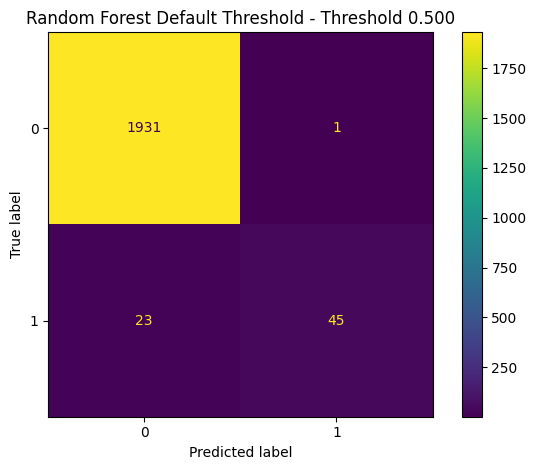

In [23]:
default_threshold_results = evaluate_with_threshold(
    best_model,
    X_val,
    y_val,
    0.5,
    best_model_name + " Default Threshold"
)

===== Random Forest Tuned Threshold at Threshold 0.190 =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.75      0.81      0.78        68

    accuracy                           0.98      2000
   macro avg       0.87      0.90      0.89      2000
weighted avg       0.99      0.98      0.98      2000

Confusion Matrix:
[[1914   18]
 [  13   55]]


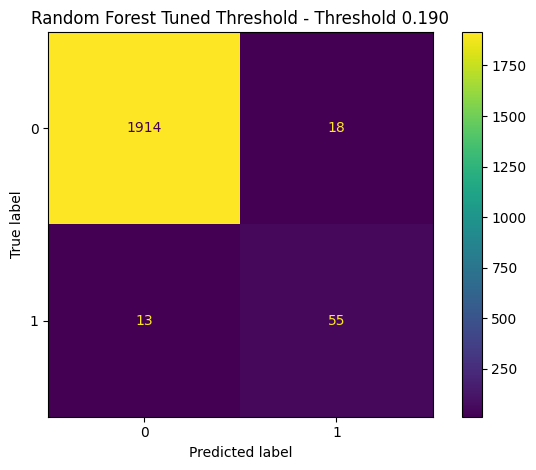

In [24]:
tuned_threshold_results = evaluate_with_threshold(
    best_model,
    X_val,
    y_val,
    best_threshold,
    best_model_name + " Tuned Threshold"
)

In [25]:
threshold_comparison_df = pd.DataFrame([
    default_threshold_results,
    tuned_threshold_results
])

threshold_comparison_df

,Model,Threshold,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Random Forest Default Threshold,0.50,0.978261,0.661765,0.789474,0.97439,0.854503
1,Random Forest Tuned Threshold,0.19,0.753425,0.808824,0.780142,0.97439,0.854503


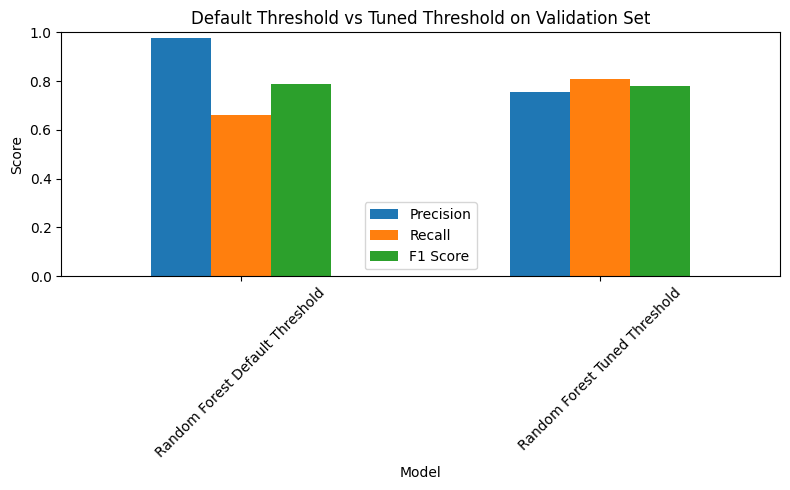

In [26]:
threshold_comparison_df.set_index('Model')[['Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Default Threshold vs Tuned Threshold on Validation Set')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig('../reports/figures/day4_default_vs_tuned_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

## Default Threshold vs Tuned Threshold

The tuned threshold was compared against the default threshold of 0.5.

Lowering the threshold usually increases recall, meaning more actual failures are detected. However, this may reduce precision and increase the number of false alarms.

## Final Test Evaluation

The final selected model was evaluated on the untouched test set using the threshold selected from the validation set.

This provides a more honest estimate of how the model may perform on unseen data.

===== Random Forest Final Test Evaluation at Threshold 0.190 =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.75      0.85      0.80        68

    accuracy                           0.99      2000
   macro avg       0.87      0.92      0.90      2000
weighted avg       0.99      0.99      0.99      2000

Confusion Matrix:
[[1913   19]
 [  10   58]]


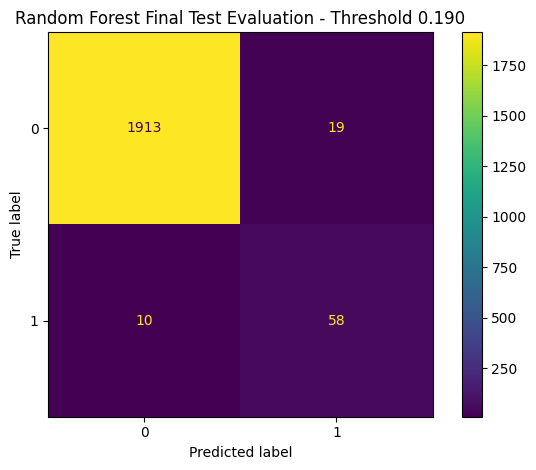

{'Model': 'Random Forest Final Test Evaluation',
 'Threshold': np.float64(0.19),
 'Precision': 0.7532467532467533,
 'Recall': 0.8529411764705882,
 'F1 Score': 0.8,
 'ROC-AUC': 0.9696748264523201,
 'PR-AUC': 0.8764805443963214}

In [27]:
final_test_results = evaluate_with_threshold(
    best_model,
    X_test,
    y_test,
    best_threshold,
    best_model_name + " Final Test Evaluation"
)

final_test_results

## Saving results in reports folder

In [28]:
validation_results_df.to_csv(
    '../reports/day4_validation_model_results.csv',
    index=False
)

threshold_comparison_df.to_csv(
    '../reports/day4_threshold_comparison.csv',
    index=False
)

pd.DataFrame([final_test_results]).to_csv(
    '../reports/day4_final_test_results.csv',
    index=False
)

# Model Improvement Insights

The candidate models were compared using a validation set instead of directly using the test set. This helps prevent overfitting decisions to the test data.

The best model based on validation PR-AUC was: Random Forest.

The default threshold of 0.5 was not assumed to be optimal because this is an imbalanced predictive maintenance problem.

A custom threshold was selected by requiring recall to be at least 80%, then choosing the threshold with the highest precision among the valid candidates.

After threshold tuning:

- Recall changed from 0.66 to 0.81
- Precision changed from 0.98 to 0.76
- F1-score changed from 0.79 to 0.78


This shows the trade-off between detecting more failures and creating more false alarms.

In an industrial maintenance setting, this trade-off may be acceptable because missing a real machine failure can be more costly than inspecting a machine unnecessarily.